# 01 · Raw REFIT House 1: inspection and cleaning

**Requirement 1 of the brief.** Inspect the *raw* REFIT files for House 1, build a small,
documented cleaning pipeline, resample to 1-minute resolution, and show the data before and
after cleaning.

| | |
|---|---|
| **Input** | `Data/extracted/raw/RAW_House1_Part1.csv`, `RAW_House1_Part2.csv` (raw release `REFIT_RAW_081116.7z`) and, for validation only, `CLEAN_House1.csv` |
| **Output** | `Data/parquet/raw_house1_clean_1min.parquet`, tables in `artifacts/tables/nb01_*`, figures in `artifacts/figures/nb01_*`, summary in `artifacts/metrics/nb01_summary.json` |
| **Code** | `src/refit_nilm/cleaning.py` (each step is a tested function, see `tests/test_cleaning.py`) |
| **Run time** | about 3–4 minutes on a laptop |

**How to read this notebook.** Each section starts with *why* the check matters, then shows
the evidence, then states the decision taken. The decisions are collected at the end.

In [1]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from refit_nilm import cleaning, io, plots
from refit_nilm import config as C

warnings.filterwarnings("ignore", category=FutureWarning)
plots.setup()
pd.set_option("display.width", 160, "display.max_columns", 30)
P = plots.PALETTE
SUMMARY: dict = {}

appliance_map = io.parse_appliance_map(C.DATA_DIR / "CLEAN_READ_ME_081116.txt")
H1 = {f"Appliance{c}": d.split(",")[0] for c, d in appliance_map[1].items()}
H1

{'Appliance1': 'Fridge',
 'Appliance2': 'Freezer(1)',
 'Appliance3': 'Freezer(2)',
 'Appliance4': 'Washer Dryer',
 'Appliance5': 'Washing Machine',
 'Appliance6': 'Dishwasher',
 'Appliance7': 'Computer',
 'Appliance8': 'Television Site',
 'Appliance9': 'Electric Heater'}

## 1. What the raw files are

The raw release splits every house into two files. According to the README, `_Part1` is the
first iteration of the database, where an unavailable sensor was written as **0**, and
`_Part2` is the second iteration, where it was written as **NaN**. The README also says that a
value was only logged when the load changed, and that the collection script polled the
sensors every 6–8 seconds without synchronising them. So rows are not a regular time series,
and a zero in Part 1 can mean either "off" or "not reporting".

All power columns are active power in watts. House 1 has an aggregate clamp plus 9 plug
monitors (IAMs); the washing machine is `Appliance5`, a washer-dryer is `Appliance4`.

In [2]:
p1 = io.read_refit_csv(C.RAW_CSV_DIR / "RAW_House1_Part1.csv")
p2 = io.read_refit_csv(C.RAW_CSV_DIR / "RAW_House1_Part2.csv")
inspection = pd.DataFrame([cleaning.inspect_raw(p1, "Part1"), cleaning.inspect_raw(p2, "Part2")]).set_index("file").T
inspection.to_csv(C.TABLE_DIR / "nb01_raw_inspection.csv")
inspection

file,Part1,Part2
rows,4377877,4140886
first_unix_as_utc,2013-10-09 14:06:17,2014-06-27 21:57:49
last_unix_as_utc,2014-10-01 01:27:07,2015-07-10 11:56:32
time_parse_failures,0,0
time_vs_unix_offset_s_max_abs,1,1
backward_steps,1,0
duplicate_unix,1004404,14755
exact_duplicate_rows,884307,393
median_interval_s,7.0,7.0
p99_interval_s,16.0,9.0


## 2. Sampling intervals

**Why.** The resampling rule and the gap-filling limit both depend on how often readings
normally arrive. If the typical spacing is 6–8 s, a 1-minute bin normally holds 7–10
readings, and a missing minute is unusual.

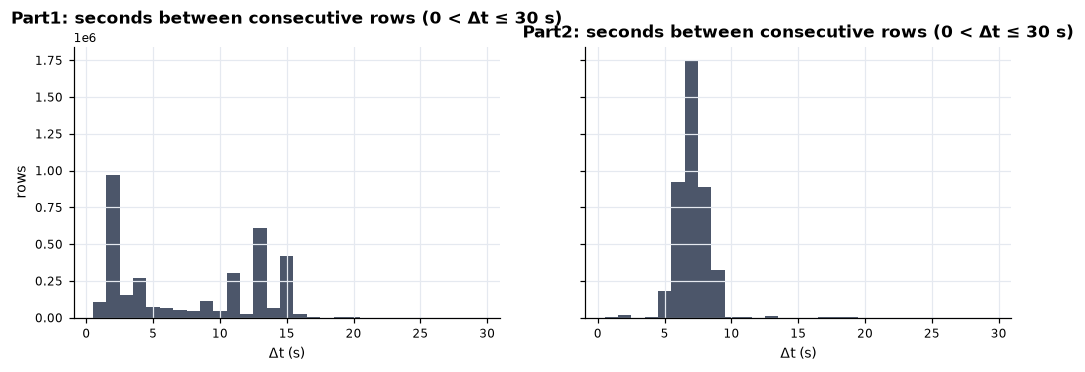

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, (name, d) in zip(axes, [("Part1", p1), ("Part2", p2)]):
    dt = np.diff(d["Unix"].to_numpy())
    dt = dt[(dt > 0) & (dt <= 30)]
    ax.hist(dt, bins=np.arange(0.5, 30.5, 1), color=P["aggregate"])
    ax.set_title(f"{name}: seconds between consecutive rows (0 < Δt ≤ 30 s)")
    ax.set_xlabel("Δt (s)")
axes[0].set_ylabel("rows")
plots.save(fig, "nb01_sampling_intervals")
plt.show()

**Reading the histogram.** Part 2 shows the documented 6–8 s polling. Part 1 also has a large
mass at 1–2 s, which comes from repeated rows (section 5): the same poll written more than
once. Both are expected from the README, but they mean that counting rows is not the same as
counting readings.

## 3. Timestamp parsing, ordering and the clock

**Why.** Everything downstream (resampling, joining aggregate and appliances, hour-of-day
analysis) depends on time being correct and monotonic. `Time` is a text rendering of `Unix`
(they differ by at most one second of rounding, see `time_vs_unix_offset_s_max_abs` above),
so `Unix` is the column to trust for ordering.

The README describes `Unix` as UTC. That can be tested directly: in the UK the clocks skip
01:00–02:00 on the last Sunday of March and repeat 01:00–02:00 on the last Sunday of
October. A file that stores **UTC** has an ordinary number of rows in both hours. A file that
stores **UK wall-clock time** has *no* rows in the spring hour and roughly *double* in the
autumn hour.

In [4]:
cc = pd.concat(
    [
        cleaning.clock_change_hours(p1["Unix"], "2013-10-01", "2014-10-02").assign(file="raw Part1"),
        cleaning.clock_change_hours(p2["Unix"], "2014-06-27", "2015-07-11").assign(file="raw Part2"),
    ]
)
official = io.read_refit_csv(io.clean_csv_path(1))
cc = pd.concat([cc, cleaning.clock_change_hours(official["Unix"], "2013-10-01", "2015-07-11").assign(file="official cleaned")])
cc = cc[["file", "date", "change", "rows_01_02", "rows_per_hour_before"]]
cc.to_csv(C.TABLE_DIR / "nb01_clock_change_hours.csv", index=False)
cc

,file,date,change,rows_01_02,rows_per_hour_before
0,raw Part1,2013-10-27,autumn (hour repeated),1199,600
1,raw Part1,2014-03-30,spring (hour skipped),0,600
0,raw Part2,2014-10-26,autumn (hour repeated),986,537
1,raw Part2,2015-03-29,spring (hour skipped),0,539
0,official cleaned,2013-10-27,autumn (hour repeated),881,400
1,official cleaned,2014-03-30,spring (hour skipped),600,680
2,official cleaned,2014-10-26,autumn (hour repeated),986,537
3,official cleaned,2015-03-29,spring (hour skipped),0,539


In [5]:
u = p1["Unix"].to_numpy()
k = int(np.argmax(np.diff(u) < 0))
SUMMARY["part1_backward_step"] = f"{pd.to_datetime(u[k], unit='s')} -> {pd.to_datetime(u[k + 1], unit='s')}"
print("Part1 backward step (row", k, "):", SUMMARY["part1_backward_step"])

Part1 backward step (row 249600 ): 2013-10-27 01:59:58 -> 2013-10-27 01:00:01


**Finding: the raw `Unix` column is UK wall-clock time, not UTC.** Both raw parts have zero
rows in the skipped spring hour and about twice the normal number in the repeated autumn
hour. The single backward step in Part 1 is exactly the autumn clock change of 27 Oct 2013
(01:59:58 → 01:00:01): the logger's clock went back an hour.

The official *cleaned* file behaves like UTC in spring 2014 but like wall-clock time in
autumn 2014 and spring 2015. Section 9 shows where that switch happens.

**Decision.** Convert raw timestamps from Europe/London wall-clock time to UTC *before*
sorting. The repeated autumn hour is resolved from file order: rows before the backward step
are summer time, rows after it are winter time. Sorting first would interleave the two hours
and make them impossible to separate. Where a file is already sorted (Part 2 in October 2014),
the hour cannot be resolved, so its rows are dropped and counted.

## 4. The two parts overlap in time

**Why.** If both parts are simply concatenated, about three months of readings are counted
twice.

In [6]:
utc1, _ = cleaning.local_epoch_to_utc(p1["Unix"].to_numpy())
utc2, _ = cleaning.local_epoch_to_utc(p2["Unix"].to_numpy())
a = p1.assign(utc=utc1).query("utc >= 0")
b = p2.assign(utc=utc2).query("utc >= 0")
lo, hi = b["utc"].min(), a["utc"].max()
ov_a, ov_b = a[a["utc"].between(lo, hi)], b[b["utc"].between(lo, hi)]
minutes = (hi - lo) / 60
ov = pd.DataFrame(
    {
        "rows": [len(ov_a), len(ov_b)],
        "rows_per_minute": [len(ov_a) / minutes, len(ov_b) / minutes],
        "aggregate_nan_pct": [100 * ov_a["Aggregate"].isna().mean(), 100 * ov_b["Aggregate"].isna().mean()],
        "iam_nan_pct": [100 * ov_a[C.CHANNELS[1:]].isna().to_numpy().mean(), 100 * ov_b[C.CHANNELS[1:]].isna().to_numpy().mean()],
    },
    index=["Part1 in overlap", "Part2 in overlap"],
).round(2)
SUMMARY["overlap_window_utc"] = [str(pd.to_datetime(lo, unit="s")), str(pd.to_datetime(hi, unit="s"))]

# agreement of each part with the official cleaned file (1-minute aggregate, true UTC)
off_utc = io.clean_unix_to_utc(official["Unix"].to_numpy(), 1)
off_series = pd.Series(official["Aggregate"].to_numpy(), index=off_utc)
off_series = off_series[off_series.index >= 0]
off_m = off_series.groupby(off_series.index // 60).mean()
for name, d in [("Part1 in overlap", ov_a), ("Part2 in overlap", ov_b)]:
    m = d.groupby(d["utc"] // 60)["Aggregate"].mean()
    j = pd.concat([m, off_m], axis=1, join="inner").dropna()
    ov.loc[name, "corr_with_official_1min"] = round(j.iloc[:, 0].corr(j.iloc[:, 1]), 3)
ov.to_csv(C.TABLE_DIR / "nb01_part_overlap.csv")
ov

,rows,rows_per_minute,aggregate_nan_pct,iam_nan_pct,corr_with_official_1min
Part1 in overlap,1257865,9.18,0.00,0.00,0.999
Part2 in overlap,945403,6.90,5.81,23.12,0.777


**Decision.** Inside the overlap window, keep Part 1 and drop Part 2; after it, use Part 2.
Part 1 is the denser source there: every row carries all ten channels, while Part 2 rows are
sparse event rows. The last column is an independent check: the official cleaned file agrees
far better with Part 1 than with Part 2 over the same minutes, so the publishers made the
same choice.

## 5. Duplicate timestamps

**Why.** Duplicates inflate averages in a resampling bin and break joins.

**Rule.** (1) Drop rows that are identical in time *and* every channel. (2) If the same
instant still has different values, keep the last row in acquisition order: it is the most
recent poll of the sensors. Both counts are reported by the pipeline in section 8.

In [7]:
dups = pd.DataFrame(
    {
        "duplicate_unix": [int(p1["Unix"].duplicated().sum()), int(p2["Unix"].duplicated().sum())],
        "exact_duplicate_rows": [int(p1.duplicated(["Unix"] + C.CHANNELS).sum()), int(p2.duplicated(["Unix"] + C.CHANNELS).sum())],
    },
    index=["Part1", "Part2"],
)
dups["same_time_different_values"] = dups["duplicate_unix"] - dups["exact_duplicate_rows"]
dups

,duplicate_unix,exact_duplicate_rows,same_time_different_values
Part1,1004404,884307,120097
Part2,14755,393,14362


## 6. Impossible and extreme values

**Why.** A few corrupt readings dominate means, energy totals and model losses.

Physical limits used:
* **Plug monitors (IAMs).** REFIT treats IAM readings above 4,000 W as malfunctions (the
  plugs are rated for a 13 A socket, about 3 kW). Values such as 32,767, 65,535 and 98,301
  are also integer-overflow sentinels, not power.
* **Aggregate.** A UK single-phase supply is fused at 60–100 A; 100 A × 230 V = 23 kW is a
  hard ceiling.
* Negative active power does not occur in a non-PV house.

In [8]:
def extreme_table(d: pd.DataFrame, name: str) -> pd.DataFrame:
    rows = []
    for col in C.CHANNELS:
        v = d[col]
        limit = cleaning.MAX_AGGREGATE_W if col == "Aggregate" else C.APPLIANCE_CLIP_W
        rows.append(
            {
                "file": name, "channel": col, "appliance": H1.get(col, "Aggregate"),
                "p99.9_W": v.quantile(0.999), "max_W": v.max(),
                "over_limit": int((v > limit).sum()), "sentinels": int(v.isin(cleaning.SENTINELS).sum()),
                "negative": int((v < 0).sum()),
            }
        )
    return pd.DataFrame(rows)


extremes = pd.concat([extreme_table(p1, "Part1"), extreme_table(p2, "Part2")])
extremes.to_csv(C.TABLE_DIR / "nb01_extreme_values.csv", index=False)
extremes[extremes["over_limit"] > 0]

,file,channel,appliance,p99.9_W,max_W,over_limit,sentinels,negative
0,Part1,Aggregate,Aggregate,10603.000,24000.0,26,0,0
1,Part1,Appliance1,Fridge,108.000,69629.0,662,24,0
2,Part1,Appliance2,Freezer(1),61.000,98301.0,18,3,0
3,Part1,Appliance3,Freezer(2),196.000,32751.0,38,0,0
4,Part1,Appliance4,Washer Dryer,1424.000,98301.0,2014,111,0
5,Part1,Appliance5,Washing Machine,2340.000,32767.0,156,2,0
6,Part1,Appliance6,Dishwasher,2285.000,14336.0,24,0,0
7,Part1,Appliance7,Computer,46.000,98299.0,3,0,0
8,Part1,Appliance8,Television Site,47.000,65549.0,88,2,0
9,Part1,Appliance9,Electric Heater,1041.000,65535.0,35,3,0


**Decision.** Impossible readings are set to **NaN (missing)**, not to 0. The official
cleaned release replaces IAM spikes with 0, which silently turns a sensor fault into "the
appliance was off". For a disaggregation target that distinction matters: a zero is a label,
a NaN is the absence of one.

The fraction of rows where the plug monitors add up to more than the aggregate is also
reported by `inspect_raw` above (`rows_iam_sum_gt_aggregate_pct`); it reflects the
unsynchronised polling and is flagged per minute after resampling rather than deleted.

## 7. Missing readings: what a NaN means

**Why.** In Part 2 a NaN usually means "this sensor did not report at this poll", because
values were only logged on change. Filling every NaN would carry values across real
outages; filling none would throw away most of the data. The question is how long a
sensor normally goes without reporting.

In [9]:
gap_q = {}
for col in ["Aggregate", "Appliance1", "Appliance5"]:
    t = b.loc[b[col].notna(), "utc"].to_numpy()
    g = np.diff(np.sort(t))
    gap_q[col] = {
        "median_s": float(np.median(g)), "p95_s": float(np.percentile(g, 95)), "p99_s": float(np.percentile(g, 99)),
        "share_le_120s_pct": float(100 * (g <= 120).mean()),
    }
gap_q = pd.DataFrame(gap_q).T.round(1)
gap_q

,median_s,p95_s,p99_s,share_le_120s_pct
Aggregate,7.0,9.0,16.0,100.0
Appliance1,7.0,13.0,24.0,100.0
Appliance5,7.0,14.0,24.0,100.0


**Decision.** Carry each channel's last reading forward for at most **120 s**. That covers
the normal reporting gaps of each sensor (see the share above) while stopping at real
outages, which are then handled at the 1-minute level.

## 8. Run the cleaning pipeline

Steps, in order (each is a function in `cleaning.py`):
1. wall-clock → UTC per part (section 3);
2. keep Part 1 in the overlap window (section 4);
3. drop exact duplicates, then keep the last poll per instant (section 5);
4. impossible values → NaN (section 6);
5. carry event rows forward ≤ 120 s (section 7);
6. **1-minute mean** on a regular UTC grid. The mean of the readings inside each minute
   preserves energy (W × minutes), which is what disaggregation is evaluated on; a
   median or last-value rule would not;
7. gaps of **≤ 3 minutes** are forward-filled (the 1-minute REFIT protocol of Petralia et
   al., KDD 2025); longer gaps stay NaN and are listed as outages, never interpolated.

In [10]:
clean_1min, long_gaps, report = cleaning.clean_raw_house(p1, p2)
rep = report.to_frame()
rep.to_csv(C.TABLE_DIR / "nb01_cleaning_report.csv", index=False)
pd.DataFrame(
    {"step": [r["step"] for r in report.steps],
     "what happened": ["; ".join(f"{k} = {v}" for k, v in r.items() if k != "step") for r in report.steps]}
).style.hide(axis="index")

step,what happened
Part1: wall-clock -> UTC,rows = 4377877; rows_shifted_by_1h = 2795917; rows_dropped_ambiguous_or_nonexistent = 0; backward_steps_before = 1
Part2: wall-clock -> UTC,rows = 4140886; rows_shifted_by_1h = 2253241; rows_dropped_ambiguous_or_nonexistent = 986; backward_steps_before = 0
resolve Part1/Part2 overlap,overlap_start_utc = 2014-06-27 20:57:49; overlap_end_utc = 2014-10-01 00:27:07; part2_rows_dropped_in_overlap = 945403; part1_rows_in_overlap = 1257865
drop duplicates,exact_duplicates_removed = 884252; conflicting_same_time_removed = 131753
mask impossible values,iam_cells_masked = 3222; aggregate_cells_masked = 59
carry event rows forward,cells_forward_filled = 2328155; limit_s = 120
resample to 1 minute,minutes = 920031; minutes_without_readings = 122187
fill short gaps / flag long gaps,short_gaps_filled = 446; minutes_filled = 631; long_gaps_flagged = 447; minutes_in_long_gaps = 121577
flag IAM sum > aggregate,minutes_flagged = 7049


## 9. Outages after cleaning

In [11]:
long_gaps = long_gaps.assign(hours=lambda d: (d["minutes"] / 60).round(1))
long_gaps.to_csv(C.TABLE_DIR / "nb01_long_gaps.csv", index=False)
total_min = len(clean_1min)
SUMMARY.update(
    {
        "minutes_total": int(total_min),
        "minutes_valid_aggregate": int(clean_1min["Aggregate"].notna().sum()),
        "coverage_pct": round(100 * clean_1min["Aggregate"].notna().mean(), 2),
        "long_gaps": int(len(long_gaps)),
        "longest_gap_hours": float(long_gaps["hours"].max()) if len(long_gaps) else 0.0,
        "minutes_imputed": int(clean_1min["imputed"].sum()),
        "first_minute_utc": str(clean_1min.index.min()),
        "last_minute_utc": str(clean_1min.index.max()),
    }
)
print({k: SUMMARY[k] for k in ["minutes_total", "coverage_pct", "long_gaps", "longest_gap_hours", "minutes_imputed"]})
long_gaps.sort_values("minutes", ascending=False).head(10)

{'minutes_total': 920031, 'coverage_pct': np.float64(86.79), 'long_gaps': 447, 'longest_gap_hours': 998.4, 'minutes_imputed': 631}


,start,end,minutes,hours
286,2014-01-24 01:57:00+00:00,2014-03-06 16:22:00+00:00,59906,998.4
422,2015-05-10 22:37:00+00:00,2015-05-19 14:09:00+00:00,12453,207.6
432,2015-06-10 12:20:00+00:00,2015-06-18 00:38:00+00:00,10819,180.3
380,2014-08-30 11:01:00+00:00,2014-09-04 10:32:00+00:00,7172,119.5
415,2015-04-03 00:44:00+00:00,2015-04-07 09:17:00+00:00,6274,104.6
412,2015-03-22 08:16:00+00:00,2015-03-24 15:22:00+00:00,3307,55.1
424,2015-05-24 09:10:00+00:00,2015-05-26 11:08:00+00:00,2999,50.0
398,2014-10-27 00:06:00+00:00,2014-10-28 13:45:00+00:00,2260,37.7
414,2015-03-31 03:23:00+00:00,2015-04-01 15:25:00+00:00,2163,36.0
409,2015-03-15 10:03:00+00:00,2015-03-16 16:15:00+00:00,1813,30.2


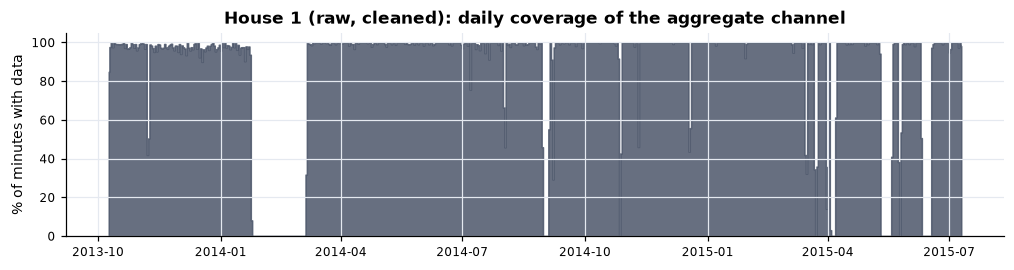

In [12]:
fig, ax = plt.subplots(figsize=(11, 2.4))
daily_cov = clean_1min["Aggregate"].notna().resample("D").mean() * 100
ax.fill_between(daily_cov.index, daily_cov.to_numpy(), color=P["aggregate"], step="mid", alpha=0.85)
ax.set_ylim(0, 105)
ax.set_ylabel("% of minutes with data")
ax.set_title("House 1 (raw, cleaned): daily coverage of the aggregate channel")
plots.save(fig, "nb01_daily_coverage")
plt.show()

## 10. Before and after cleaning

**What to look for.** The *before* panels show the raw rows exactly as stored (wall-clock
timestamps, duplicates, sentinel spikes). The *after* panels show the cleaned 1-minute UTC
series. The day is chosen programmatically as the summer-time day with the most impossible readings
on the plotted appliance channels, so the masking rule and the one-hour clock correction are
both visible. The week view is centred on a 2–12 hour outage and shows that such gaps are
kept as gaps instead of being bridged.

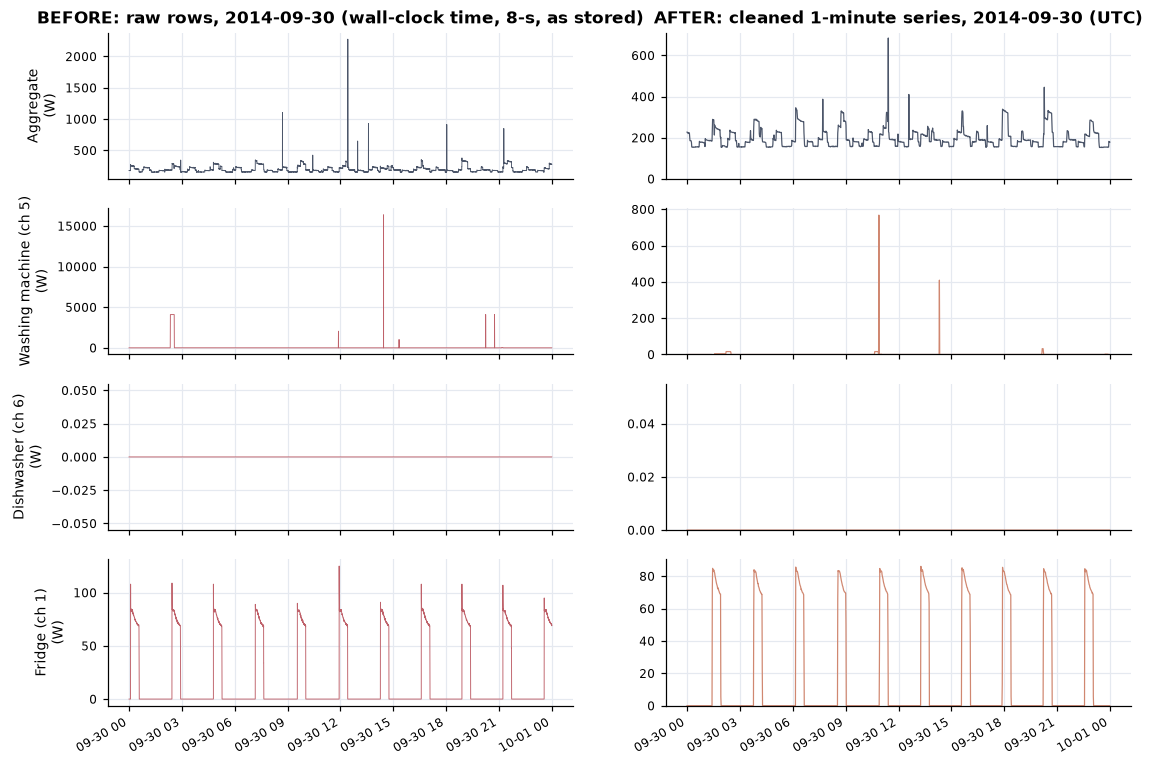

In [13]:
shown_iams = ["Appliance1", "Appliance5", "Appliance6"]
bad = (p1[shown_iams] > C.APPLIANCE_CLIP_W).any(axis=1) | p1[shown_iams].isin(cleaning.SENTINELS).any(axis=1)
cand = pd.to_datetime(p1.loc[bad, "Unix"], unit="s").dt.floor("D")
cand = cand[(cand.dt.month >= 4) & (cand.dt.month <= 9)]
day = cand.value_counts().index[0] if len(cand) else pd.Timestamp("2014-06-15")
SUMMARY["before_after_day"] = str(day.date())

show = [("Aggregate", "Aggregate"), ("Appliance5", "Washing machine (ch 5)"), ("Appliance6", "Dishwasher (ch 6)"), ("Appliance1", "Fridge (ch 1)")]
d0 = day.value // 10**9
raw_day = p1[(p1["Unix"] >= d0) & (p1["Unix"] < d0 + 86400)]
raw_t = pd.to_datetime(raw_day["Unix"], unit="s")
cl_day = clean_1min.loc[str(day.date())]

fig, axes = plt.subplots(len(show), 2, figsize=(12, 9), sharex="col")
for r, (col, label) in enumerate(show):
    axes[r, 0].plot(raw_t, raw_day[col], lw=0.6, color=P["flag"] if col != "Aggregate" else P["aggregate"])
    axes[r, 1].plot(cl_day.index.tz_localize(None), cl_day[col], lw=0.8, color=P["wm"] if col != "Aggregate" else P["aggregate"])
    axes[r, 0].set_ylabel(f"{label}\n(W)")
for ax in axes[:, 1]:
    ax.set_ylim(bottom=0)
axes[0, 0].set_title(f"BEFORE: raw rows, {day.date()} (wall-clock time, 8-s, as stored)")
axes[0, 1].set_title(f"AFTER: cleaned 1-minute series, {day.date()} (UTC)")
fig.autofmt_xdate()
plots.save(fig, "nb01_before_after_day")
plt.show()

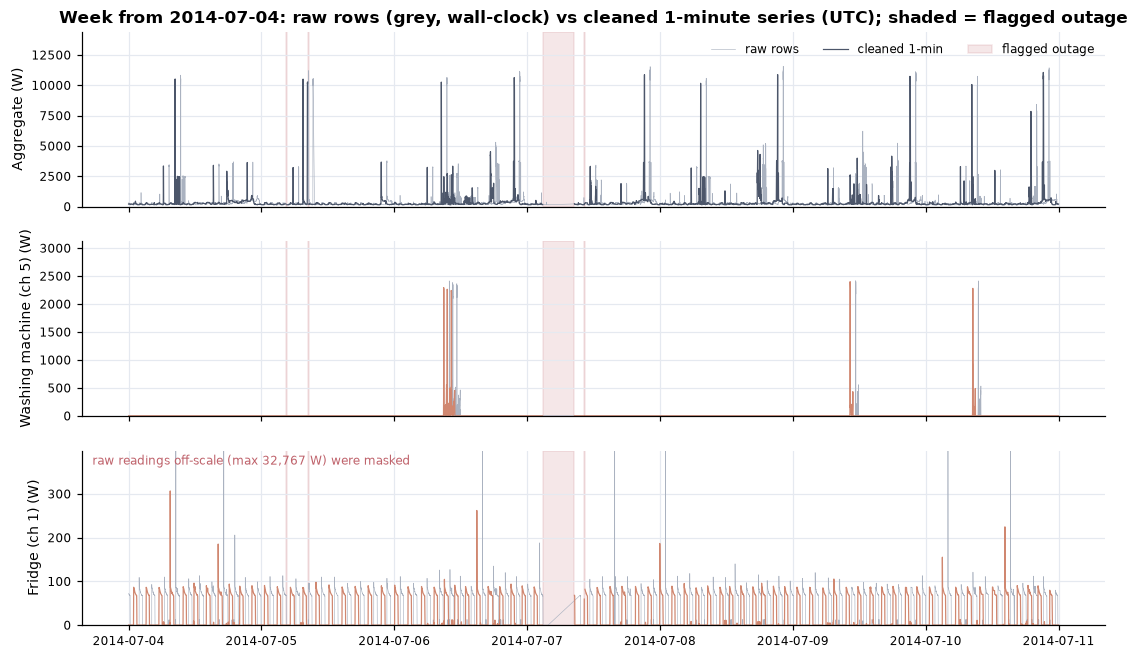

In [14]:
mid_gaps = long_gaps[(long_gaps["minutes"] >= 120) & (long_gaps["minutes"] <= 720)]
gap_start = mid_gaps.sort_values("minutes", ascending=False)["start"].iloc[0]
week_start = pd.Timestamp(gap_start).tz_localize(None).floor("D") - pd.Timedelta("3D")
SUMMARY["before_after_week_start"] = str(week_start.date())
w0 = week_start.value // 10**9
raw_w = p1[(p1["Unix"] >= w0) & (p1["Unix"] < w0 + 7 * 86400)]
cl_w = clean_1min.loc[str(week_start.date()) : str((week_start + pd.Timedelta("6D")).date())]
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for ax, (col, label) in zip(axes, [show[0], show[1], show[3]]):
    ax.plot(pd.to_datetime(raw_w["Unix"], unit="s"), raw_w[col], lw=0.4, color="#AAB2C0", label="raw rows")
    ax.plot(cl_w.index.tz_localize(None), cl_w[col], lw=0.8, color=P["wm"] if col != "Aggregate" else P["aggregate"], label="cleaned 1-min")
    gaps = cl_w["long_gap"]
    if gaps.any():
        ax.fill_between(cl_w.index.tz_localize(None), 0, 1, where=gaps.to_numpy(), transform=ax.get_xaxis_transform(), color=P["flag"], alpha=0.15, label="flagged outage")
    ax.set_ylabel(f"{label} (W)")
    top = 1.3 * float(np.nanmax(cl_w[col].to_numpy()))
    ax.set_ylim(0, top)
    raw_max = float(raw_w[col].max())
    if raw_max > top:
        ax.text(0.01, 0.92, f"raw readings off-scale (max {raw_max:,.0f} W) were masked", transform=ax.transAxes, fontsize=8, color=P["flag"])
axes[0].legend(loc="upper right", ncol=3)
axes[0].set_title(f"Week from {week_start.date()}: raw rows (grey, wall-clock) vs cleaned 1-minute series (UTC); shaded = flagged outage")
plots.save(fig, "nb01_before_after_week")
plt.show()

## 11. Validation against the official cleaned release

**Why.** The brief does not ask me to reproduce the official cleaning, but the official file
is an independent reference. If my pipeline is correct, my 1-minute series should match the
official one closely wherever both have data; the residual differences should be explained by
documented choices (NaN vs 0 for faulty IAM readings, gap handling).

The official file needs one correction of its own before the comparison: the rows that came
from raw Part 1 were converted to UTC by the publishers, but rows that came only from raw
Part 2 (after Part 1 ends on 1 Oct 2014) still hold wall-clock time (section 3). The table
below locates that switch by comparing each month of the official file with my cleaned series
at a 0 h and a 1 h offset.

In [15]:
off_raw = official.copy()
off_raw_m = off_raw.groupby(off_raw["Unix"] // 60)[C.CHANNELS].mean()
off_raw_m.index = pd.to_datetime(off_raw_m.index * 60, unit="s", utc=True)
mine = clean_1min[C.CHANNELS]
rows = []
for month in pd.period_range("2013-10", "2015-07", freq="M"):
    a_ = mine.loc[(mine.index >= month.start_time.tz_localize("UTC")) & (mine.index <= month.end_time.tz_localize("UTC")), "Aggregate"]
    if a_.notna().sum() < 2000:
        continue
    rec = {"month": str(month)}
    for lag in (0, 60):
        b_ = off_raw_m["Aggregate"].shift(-lag)  # official minute t+lag vs mine at t
        j = pd.concat([a_, b_], axis=1, join="inner").dropna()
        rec[f"corr_official_shift_{lag}min"] = round(j.iloc[:, 0].corr(j.iloc[:, 1]), 3)
    rows.append(rec)
regime = pd.DataFrame(rows)
regime.to_csv(C.TABLE_DIR / "nb01_official_time_regime.csv", index=False)
regime

,month,corr_official_shift_0min,corr_official_shift_60min
0,2013-10,0.999,0.245
1,2013-11,0.999,0.195
2,2013-12,0.999,0.173
3,2014-01,0.999,0.193
4,2014-03,1.000,0.365
5,2014-04,1.000,0.098
6,2014-05,0.999,0.057
7,2014-06,0.999,0.046
8,2014-07,0.998,0.022
9,2014-08,0.999,0.033


Reading the table: in summer-time months *before* October 2014 the official file lines up
with my UTC series at 0 h (it is UTC), while in summer-time months of 2015 it lines up only
when shifted by one hour (it is wall-clock time). In winter both offsets coincide because UK
winter time equals UTC. The loader `io.load_clean_minutes` therefore maps the official files
to true UTC per house, using the date at which each house's raw Part 1 ends
(`artifacts/tables/raw_part1_end.csv`).

In [16]:
official_utc = io.load_clean_minutes(1)
both = mine.join(official_utc[C.CHANNELS], rsuffix="_off", how="inner")
val = []
for col in C.CHANNELS:
    j = both[[col, col + "_off"]].dropna()
    val.append(
        {
            "channel": col, "appliance": H1.get(col, "Aggregate"), "minutes_compared": len(j),
            "corr": round(j[col].corr(j[col + "_off"]), 4),
            "mae_W": round((j[col] - j[col + "_off"]).abs().mean(), 2),
            "energy_mine_kWh": round(j[col].sum() / 60_000, 1), "energy_official_kWh": round(j[col + "_off"].sum() / 60_000, 1),
        }
    )
val = pd.DataFrame(val)
val.to_csv(C.TABLE_DIR / "nb01_validation_vs_official.csv", index=False)
SUMMARY["validation_aggregate_corr"] = float(val.loc[val.channel == "Aggregate", "corr"].iloc[0])
SUMMARY["validation_wm_corr"] = float(val.loc[val.channel == "Appliance5", "corr"].iloc[0])
val

,channel,appliance,minutes_compared,corr,mae_W,energy_mine_kWh,energy_official_kWh
0,Aggregate,Aggregate,797699,0.9993,2.99,6368.6,6368.7
1,Appliance1,Fridge,796415,0.9981,0.05,234.1,234.0
2,Appliance2,Freezer(1),795768,0.9958,0.08,220.5,220.5
3,Appliance3,Freezer(2),796313,0.9995,0.06,386.6,386.5
4,Appliance4,Washer Dryer,797432,0.9996,0.02,25.1,25.1
5,Appliance5,Washing Machine,791749,0.9992,0.13,143.4,143.3
6,Appliance6,Dishwasher,797652,0.9998,0.05,149.8,149.8
7,Appliance7,Computer,797695,0.9973,0.01,33.1,33.0
8,Appliance8,Television Site,796793,0.9996,0.02,77.6,77.6
9,Appliance9,Electric Heater,707985,0.9998,0.22,900.9,901.1


## 12. Save outputs

In [17]:
out_path = C.PARQUET_DIR / "raw_house1_clean_1min.parquet"
clean_1min.to_parquet(out_path)
SUMMARY["report"] = report.steps
(C.METRIC_DIR).mkdir(parents=True, exist_ok=True)
with open(C.METRIC_DIR / "nb01_summary.json", "w") as fh:
    json.dump(SUMMARY, fh, indent=2, default=str)
print("saved:", out_path.relative_to(C.PROJECT_ROOT))

saved: Data\parquet\raw_house1_clean_1min.parquet


## Summary

**What the raw House 1 data looks like.** Two files, 4.38 M and 4.14 M rows, covering
9 Oct 2013 – 10 Jul 2015 at a median spacing of 7 s. Active power only, in watts.

| Issue found | Evidence | Decision |
|---|---|---|
| Raw `Unix` is UK wall-clock time, not UTC | no rows in the skipped spring hour, ~2× rows in the repeated autumn hour; one backward step exactly at the 27 Oct 2013 clock change | convert Europe/London → UTC **before** sorting; repeated hour resolved by file order (2.80 M Part 1 and 2.25 M Part 2 rows shifted; 986 Part 2 rows in an already-sorted repeated hour dropped) |
| Part 1 and Part 2 overlap (27 Jun – 1 Oct 2014) | Part 1 is denser and complete; the official file agrees with Part 1 (r = 0.999) far more than with Part 2 (r = 0.777) | keep Part 1 in the overlap (945 k Part 2 rows dropped) |
| Duplicate timestamps | 884 k exact duplicate rows; 132 k same-instant rows with different values | drop exact duplicates; keep the last poll per instant |
| Impossible values | IAM readings > 4 kW and overflow sentinels (32,767 / 65,535 / 98,301); aggregate > 23 kW | 3,222 IAM and 59 aggregate cells set to **NaN** (missing), not 0 |
| Event-style NaNs in Part 2 | a sensor is only written when it changes | carry each channel forward ≤ 120 s (2.33 M cells) |
| Missing minutes | 122 k minutes without any reading after resampling | 446 gaps of ≤ 3 min forward-filled (631 min); 447 longer gaps (≈ 84 days) **flagged, not filled** |
| Plug monitors sum to more than the aggregate | unsynchronised polling | 7,049 minutes flagged (`issues = 1`), kept |

**Result.** 920,031 one-minute rows on a regular UTC grid, 86.8 % with a valid aggregate.
The longest outage is 41.6 days (24 Jan – 6 Mar 2014), the network outage documented by the
dataset authors.

**Validation.** Against the official cleaned release (mapped to true UTC), my independent
pipeline reproduces the aggregate with r = 0.9993 and a mean absolute difference of 3.0 W, the
washing machine with r = 0.9992, and every channel's total energy to within 0.2 kWh.

**A problem in the official cleaned release.** Its timestamps are UTC only up to the date each
house's raw Part 1 ends (about 1 Oct 2014). After that they are wall-clock time again, so
summer-time readings in 2015 sit one hour late. Every later notebook loads the official files
through `io.load_clean_minutes`, which applies this correction per house.

**Remaining concerns.**
* In Part 1 a sensor that was not reporting was written as 0, so "off" and "not reporting"
  cannot be told apart there.
* The washer-dryer channel (`Appliance4`) carries over 2,000 impossible readings in Part 1,
  so that channel is unreliable in this house.
* A 1-minute mean smooths 8-second peaks: energy is preserved, peak power is not. A 10 kW
  spike lasting 30 s appears as about 5 kW.

## Verification log

* Clock (programmatic): counted rows in each clock-change hour (zero rows in the skipped spring
  hours, about double in the repeated autumn hours) and printed the rows around Part 1's single
  backward step (row 249,600: 01:59:58 → 01:00:01 on 27 Oct 2013).
* Day plot (visual): the washing-machine activity sits one hour earlier in the cleaned (UTC) panel
  than in the raw (wall-clock) panel, and the 4–16 kW plug readings are gone after cleaning.
* Each cleaning step has a unit test with a hand-computed answer (`tests/test_cleaning.py`).
* Independent comparison with the official release (programmatic, section 11): r ≥ 0.995 and
  total energy within 0.2 kWh on every channel.

**Next:** `02_washing_machine_eda` uses the official cleaned data for all houses with a
washing machine.